Topic 105 | Decision Trees - Data Splitting & Feature Selection - Part II

In [4]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import make_classification


In [10]:
from sklearn.datasets import make_classification

# Make a simple binary dataset
X, Y = make_classification(
    n_samples=12,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

feature_name = ["feature_1", "feature_2"]

print("\nDataset (first 8 samples)")

for i in range(8):
    print(
        f"{feature_name[0]} = {X[i,0]:.2f}, "
        f"{feature_name[1]} = {X[i,1]:.2f}, "
        f"class: {Y[i]}"
    )


Dataset (first 8 samples)
feature_1 = -1.09, feature_2 = -0.63, class: 0
feature_1 = -0.94, feature_2 = -1.36, class: 0
feature_1 = -1.03, feature_2 = 0.30, class: 1
feature_1 = -1.66, feature_2 = 2.89, class: 1
feature_1 = 0.10, feature_2 = 0.80, class: 1
feature_1 = -0.55, feature_2 = -2.59, class: 0
feature_1 = 3.00, feature_2 = -0.15, class: 1
feature_1 = -0.09, feature_2 = 0.91, class: 1


In [11]:
#train a shellow decision tree
tree = DecisionTreeClassifier(
    max_depth=2,
    criterion="gini",
    random_state=45
)
tree.fit(X,Y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",45
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [12]:
# disply how tree split
print("\nDecision tree structure")
print(export_text(tree, feature_names=feature_name))


Decision tree structure
|--- feature_2 <= -0.19
|   |--- class: 0
|--- feature_2 >  -0.19
|   |--- feature_1 <= 0.78
|   |   |--- class: 1
|   |--- feature_1 >  0.78
|   |   |--- class: 1



In [13]:
print("\nfeature importance (how much each feature was use) ")
for name, importance in zip(feature_name, tree.feature_importances_):
    print(f'{name}, {importance}')


feature importance (how much each feature was use) 
feature_1, 0.08163265306122457
feature_2, 0.9183673469387754


Topic 106 | Decision Trees - Tree Depth & Overfitting

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [7]:
# create toy dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# create toy dataset
X, Y = make_moons(n_samples=500, noise=0.25, random_state=12)

# split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# train tree with different depths
depths = list(range(1, 15))

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))
    print("Depths:", depths)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Depths: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Training Accuracy: [0.8428571428571429, 0.9142857142857143, 0.9142857142857143, 0.92, 0.9428571428571428, 0.9542857142857143, 0.9685714285714285, 0.98, 0.9885714285714285, 1.0, 1.0, 1.0, 1.0, 1.0]
Testing Accuracy: [

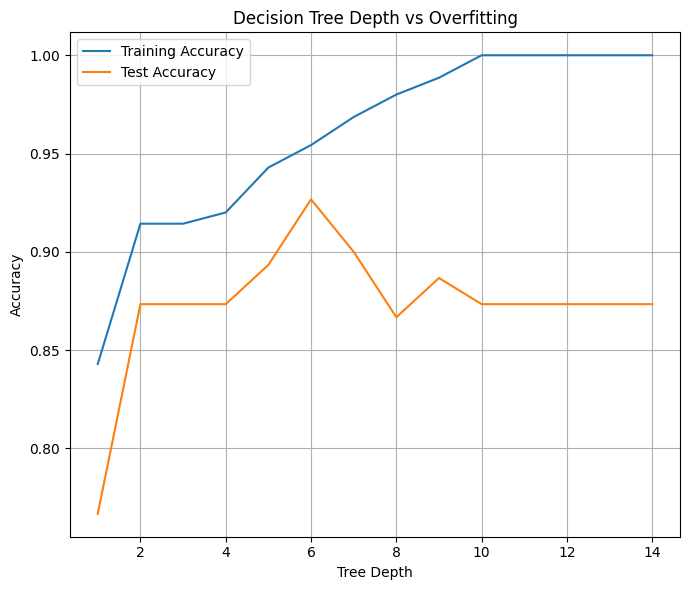

In [12]:
# plot performance
plt.figure(figsize=(7, 6))

plt.plot(depths, train_acc, label="Training Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Depth vs Overfitting")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [14]:
# print key observation
best_depth = depths[np.argmax(test_acc)]

print(f"Best depth based on test accuracy: {best_depth}")

Best depth based on test accuracy: 6


Topic 107 | Decision Trees - Pruning Techniques

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [16]:
# create toy dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# create toy dataset
X, Y = make_moons(n_samples=600, noise=0.25, random_state=42)

# split dataset
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [18]:
# pre pruning (early stop)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# train tree with different depths
depths = list(range(1, 15))

train_acc_pre = []
test_acc_pre = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,   #pre puruning control
        min_samples_leaf=5, #another prepruning control
        random_state=42
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_acc_pre.append(accuracy_score(y_train, train_pred))
    test_acc_pre.append(accuracy_score(y_test, test_pred))
    
test_acc_pre

[0.8111111111111111,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9]

In [21]:
# post pruning (cost complexity pruning)

full_tree = DecisionTreeClassifier(random_state=45)
full_tree.fit(x_train, y_train)

# compute pruning path
path = full_tree.cost_complexity_pruning_path(x_train, y_train)

ccp_alphas = path.ccp_alphas   # cost complexity values for pruning

train_acc_post = []
test_acc_post = []

for alpha in ccp_alphas:
    pruned_tree = DecisionTreeClassifier(
        ccp_alpha=alpha,   # correct parameter name
        random_state=42
    )

    pruned_tree.fit(x_train, y_train)

    train_acc_post.append(
        accuracy_score(y_train, pruned_tree.predict(x_train))
    )

    test_acc_post.append(
        accuracy_score(y_test, pruned_tree.predict(x_test))
    )

test_acc_post

[0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9111111111111111,
 0.9111111111111111,
 0.9111111111111111,
 0.9055555555555556,
 0.8888888888888888,
 0.9,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.8611111111111112,
 0.8111111111111111,
 0.49444444444444446]

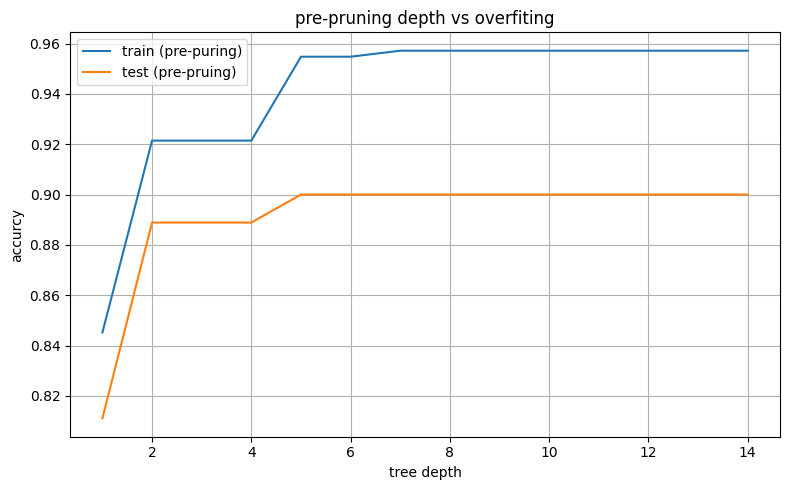

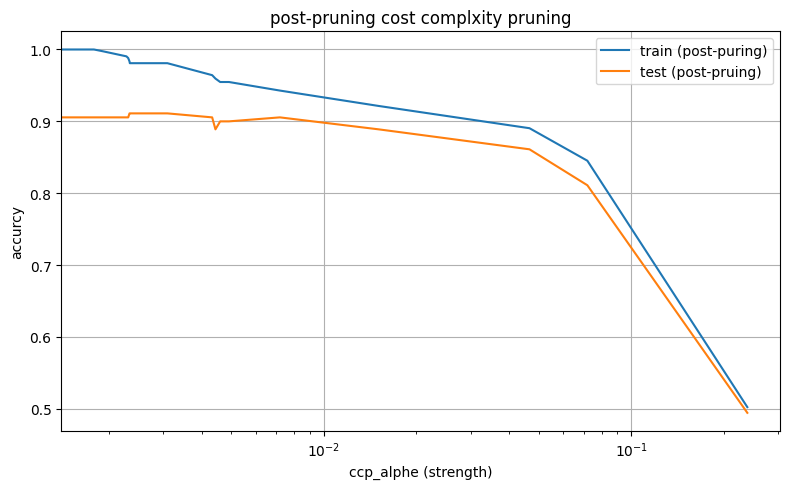

In [22]:
# disply result
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc_pre, label="train (pre-puring)")
plt.plot(depths, test_acc_pre, label="test (pre-pruing)")
plt.xlabel("tree depth")
plt.ylabel("accurcy")
plt.title("pre-pruning depth vs overfiting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_acc_post, label="train (post-puring)")
plt.plot(ccp_alphas, test_acc_post, label="test (post-pruing)")
plt.xscale("log")
plt.xlabel("ccp_alphe (strength)")
plt.ylabel("accurcy")
plt.title("post-pruning cost complxity pruning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [27]:
best_ccp_alpha=ccp_alphas[np.argmax(test_acc_post)]
print(f"ccp value base on test alpha",{best_ccp_alpha})

ccp value base on test alpha {np.float64(0.002330827067669173)}


Topic 108 | Decision Trees - Implementation with Scikit-Learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# load dataset
data = load_iris()

X = data.data
Y = data.target

feature_names = data.feature_names
class_names = data.target_names

# split into train and test set
x_train, x_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)

print(x_train.shape)
print(x_test.shape)

(105, 4)
(45, 4)


In [4]:

# fit decision tree model
model = DecisionTreeClassifier(
    max_depth=3,   # keep tree readable for teaching
    criterion='entropy',
    random_state=42
)

# train model
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

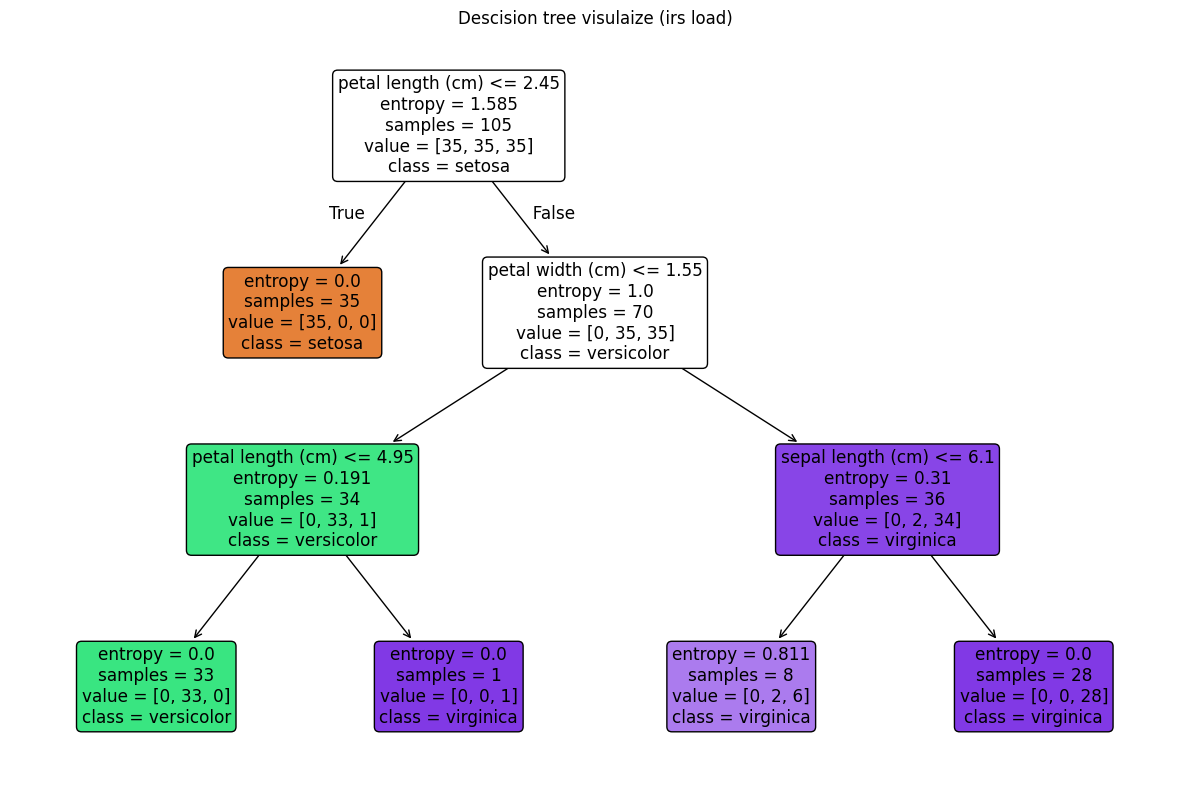

In [7]:
# visualize the descsion tree
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)

plt.title("Descision tree visulaize (irs load)")
plt.tight_layout()
plt.show()

In [9]:
#Evaluate model performance
y_pred= model.predict(x_test)
print("model parforamance")
print(f"Accuracy {accuracy_score(y_test,y_pred):.3f}")

print("confusion_matrix")
print(f"Confusion {confusion_matrix(y_test,y_pred)}")

print("classification_report")
print(f"Classfication {classification_report(y_test, y_pred, target_names=class_names)}")


model parforamance
Accuracy 0.933
confusion_matrix
Confusion [[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]
classification_report
Classfication               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45

